In [250]:
import pandas as pd
from database.adatabase import ADatabase
from datetime import datetime, timedelta
from tqdm import tqdm
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

In [251]:
market = ADatabase("market")

In [252]:
factors = [str(i) for i in range(10)]

In [253]:
market.connect()
prices = market.query("futures",{"ticker":"XRP-PERP-INTX"})
market.disconnect()

In [254]:
prices

,start,low,high,open,close,volume,ticker
0,1708653000,0.5412,0.5412,0.5412,0.5412,2391,XRP-PERP-INTX
1,1708652940,0.5412,0.5413,0.5413,0.5413,10770,XRP-PERP-INTX
2,1708652880,0.5412,0.5413,0.5412,0.5413,3751,XRP-PERP-INTX
3,1708652820,0.5411,0.5412,0.5412,0.5411,13844,XRP-PERP-INTX
4,1708652760,0.5412,0.5412,0.5412,0.5412,4535,XRP-PERP-INTX
...,...,...,...,...,...,...,...
153992,1694829840,0.5017,0.5017,0.5017,0.5017,390,XRP-PERP-INTX
153993,1694829780,0.5014,0.5016,0.5014,0.5016,6032,XRP-PERP-INTX
153994,1694829720,0.5013,0.5013,0.5013,0.5013,260,XRP-PERP-INTX
153995,1694829660,0.5011,0.5011,0.5011,0.5011,1812,XRP-PERP-INTX


In [255]:
prices["date"] = [datetime.fromtimestamp(float(x)) for x in prices["start"]]
prices.sort_values("date",inplace=True)
prices["close"] = [float(x) for x in prices["close"]]
prices["rolling"] = prices["close"].rolling(30).mean()
prices["rolling_mean"] = prices["close"].rolling(window=30).mean()
prices["rolling_std"] = prices["close"].rolling(window=30).std()
for i in range(10):
    prices[str(i)] = prices["close"].shift(i)
prices["y"] = prices["close"].shift(-5)
prices.dropna(inplace=True)
training = prices.iloc[-20000:-10000]
predictions = prices.iloc[-10000:]
model = XGBRegressor(fit_intercept=True)
model.fit(training[factors],training["y"])
predictions["prediction"] =  model.predict(predictions[factors])
prices = predictions[["date","rolling","rolling_mean","rolling_std","close","prediction"]].copy()

prices["return"] = prices["close"].pct_change()

## moving average
prices["signal"] = prices["rolling"] < prices["close"]

# ai
# prices["signal"] = prices["prediction"] < prices["close"]

# prices["signal"] = prices["rolling"] > prices["close"].rolling(30*2).mean()
prices["signal"] = [1 if x == True else - 1 for x in prices["signal"]]


# Calculate upper and lower Bollinger Bands
# prices["upper_band"] = prices["rolling_mean"] + 2 * prices["rolling_std"]
# prices["lower_band"] = prices["rolling_mean"] - 2 * prices["rolling_std"]
# prices["signal"] = 0  # 0 indicates no signal initially
# prices.loc[prices["close"] < prices["lower_band"], "signal"] = 1
# prices.loc[prices["close"] > prices["upper_band"], "signal"] = -1
# prices["signal"] = prices["signal"].replace(0, method="ffill")
# prices.drop(["rolling_mean", "rolling_std", "upper_band", "lower_band"], axis=1, inplace=True)

C:\Users\eric\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [09:36:06] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "fit_intercept" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\eric\AppData\Local\Temp\ipykernel_14108\1232077928.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictions["prediction"] =  model.predict(predictions[factors])


In [256]:
prices

,date,rolling,rolling_mean,rolling_std,close,prediction,return,signal
10004,2024-02-15 21:09:00,0.550450,0.550450,0.000573,0.5493,0.548916,NaN,-1
10003,2024-02-15 21:10:00,0.550430,0.550430,0.000589,0.5497,0.549148,0.000728,-1
10002,2024-02-15 21:11:00,0.550357,0.550357,0.000684,0.5485,0.548478,-0.002183,-1
10001,2024-02-15 21:12:00,0.550323,0.550323,0.000696,0.5496,0.548789,0.002005,-1
10000,2024-02-15 21:13:00,0.550280,0.550280,0.000705,0.5495,0.548431,-0.000182,-1
...,...,...,...,...,...,...,...,...
9,2024-02-23 10:41:00,0.542437,0.542437,0.000574,0.5423,0.543563,-0.000184,-1
8,2024-02-23 10:42:00,0.542390,0.542390,0.000532,0.5422,0.541580,-0.000184,-1
7,2024-02-23 10:43:00,0.542350,0.542350,0.000506,0.5421,0.541808,-0.000184,-1
6,2024-02-23 10:44:00,0.542300,0.542300,0.000493,0.5417,0.541580,-0.000738,-1


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:03<00:00, 3155.86it/s]


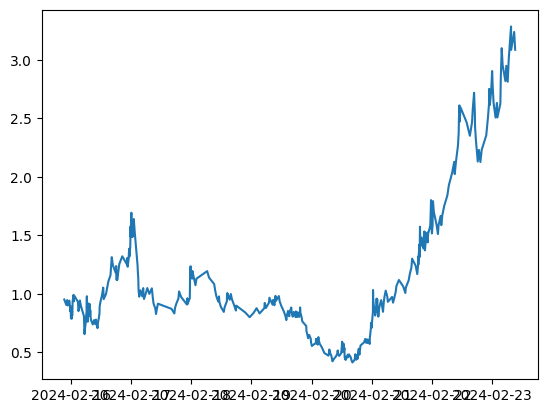

In [257]:
state = {
    "filled":False,
    "signal":0,
    "buy_price":0,
    "sell_price":0
}
profittake = 0.003
stoploss = 0.003
callback = .001
leverage = 15
states = []
for date in tqdm(prices["date"]):
    try:
        current_market = prices[prices["date"]==date] 
        current_price = current_market["close"].item()
        asset_return = current_market["return"].item()
        signal = current_market["signal"].item()
        if state["filled"]==False:
            state["signal"] = signal
            state["buy_price"] = current_price
            state["sell_price"] = current_price
            state["buy_date"] = date
            state["filled"] = True
        else:
            returns = state["signal"] * (current_price - state["buy_price"]) / state["buy_price"]
            # if (asset_return * state["signal"] < -callback and returns > profittake) or returns < -stoploss:
            if returns > profittake or returns < -stoploss:
            # if signal != state["signal"]:
                state["sell_price"] = current_price
                state["sell_date"] = date
                states.append(state.copy())
                state = {
                    "filled":False,
                    "signal":0,
                    "buy_price":0,
                    "sell_price":0
                }
    except:
        continue
trades = pd.DataFrame(states)
trades["return"] = ((trades["sell_price"] - trades["buy_price"]) / trades["buy_price"] * leverage * trades["signal"] + 1)
trades["cr"] = trades["return"].cumprod()
plt.plot(trades["sell_date"].values,trades["cr"].values)
plt.show()